In [1]:
using CairoMakie
using NCDatasets
using Oceananigans
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [5]:
using Interpolations
using NaNStatistics

In [2]:
#for energetics we need snapshot files
ds = NCDataset(string("/pub/hfdrake/code/HorizontalConvection/output/turbulent_h0.0_section_snapshots.nc"));



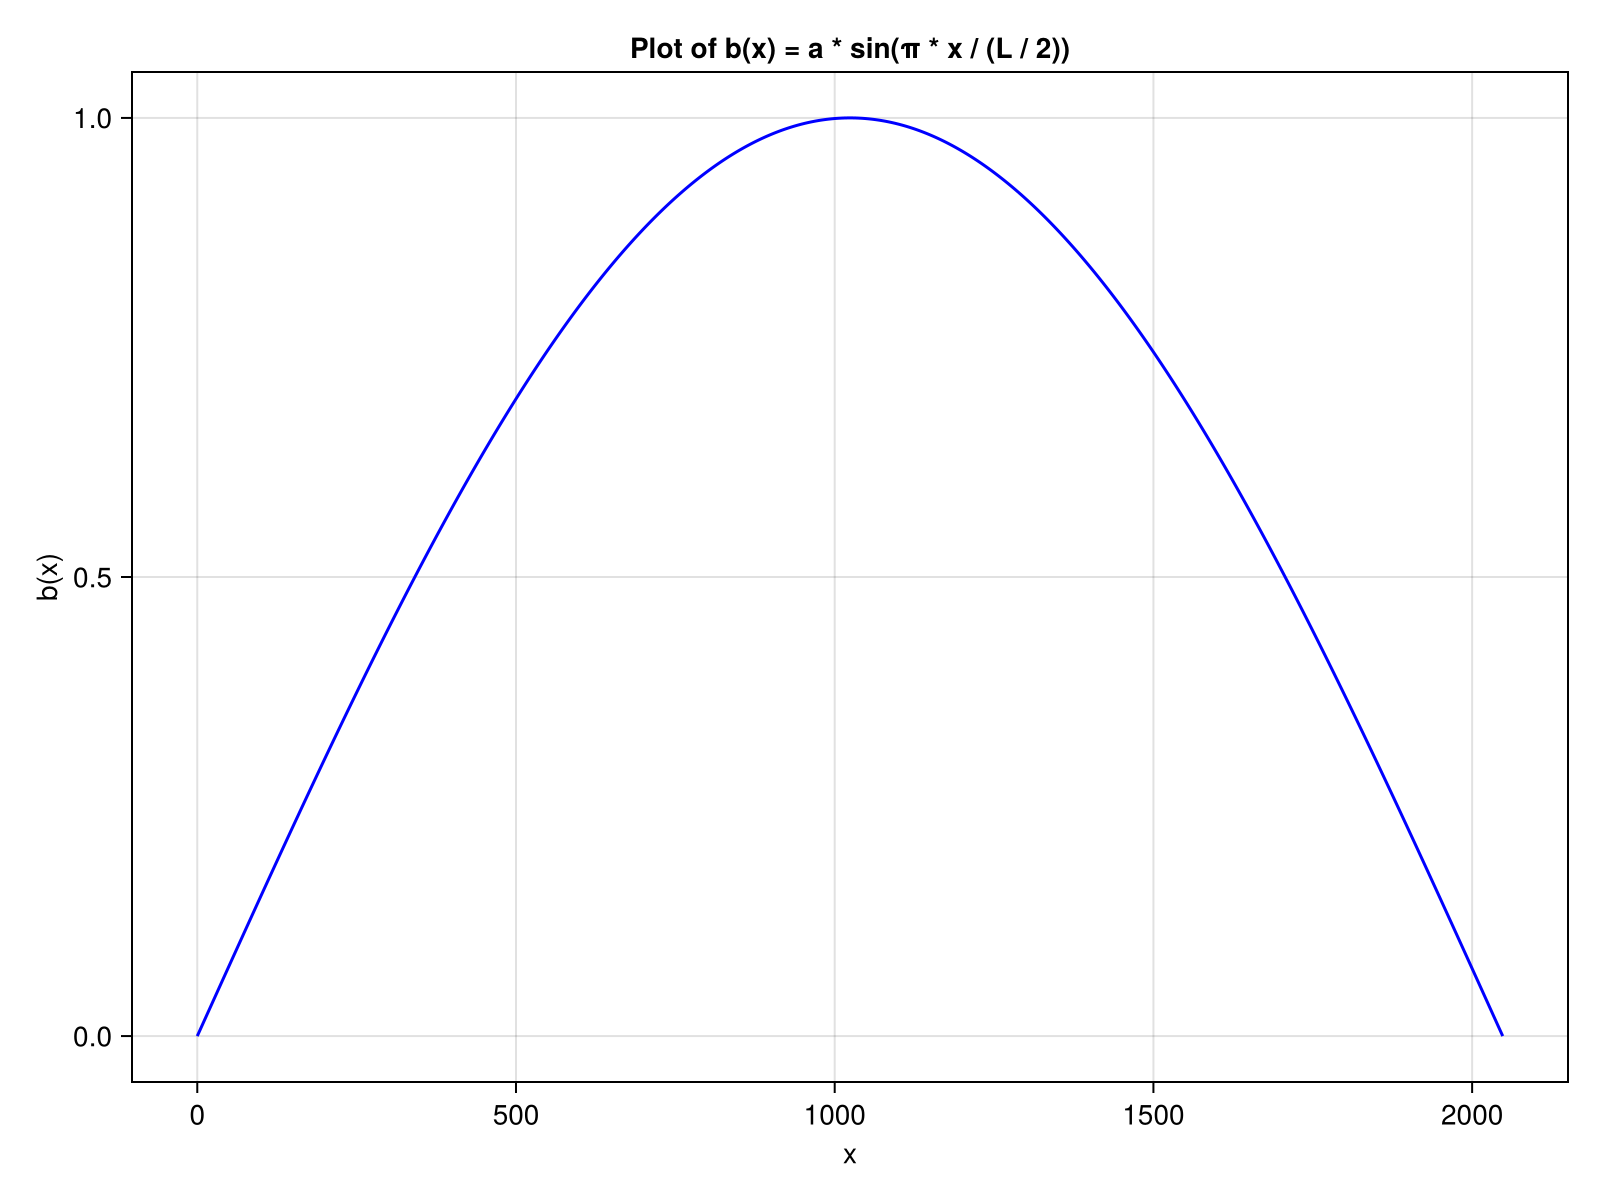

In [4]:
L=2048
bstar = 1
b(x) = bstar * sin(π * x / L)

x = range(0, stop=L, length=1000)
y = b.(x)

fig = Figure(size = (800, 600))

ax = Axis(fig[1, 1], title = "Plot of b(x) = a * sin(π * x / (L / 2))", xlabel = "x", ylabel = "b(x)")
lines!(ax, x, y, label = "b(x)", color = :blue)

fig

In [7]:
b = ds["b"][4+1:end-4, 1:1, 4+1:end-4, :];

x = ds["xC"][4+1:end-4]; Nx = length(x)
Ny = 1
z = ds["zC"][4+1:end-4]; Nz = length(z);

Δx = reshape(diff(ds["xF"])[4+1:end-4], Nx,1,1);
Δy = 1.; # periodic in y so just left positions
Δz = reshape(diff(ds["zF"])[4+1:end-4], 1,1,Nz);
ΔA = Δx.*Δy;
ΔV = ΔA.*Δz;

In [8]:
function calc_BPE(b)
    
    wet = b.!=0.;
    b[.!wet] .= NaN;
    
    z_3d = repeat(reshape(z, 1,1,Nz), Nx, Ny, 1);
    b_flat = reshape(b, (Nx*Ny*Nz));
    wet_flat = reshape(wet, (Nx*Ny*Nz));
    z_flat = reshape(z_3d, (Nx*Ny*Nz));
    
    sort_idx = sortperm(b_flat);
    b_sorted, z_sorted = b_flat[sort_idx], z_flat[sort_idx];
    
    ΔV_flat = ΔV[sort_idx];
    
    A_wet = dropdims(sum(wet.*ΔA, dims=(1,2)), dims=(1,2));
    A_interpolation = linear_interpolation(z, A_wet, extrapolation_bc=Line());
    
    z_bot = ds["zF"][5] # ignore 4 halo points
    zstar_flat = zeros(size(b_sorted))
    zstar_flat[1] = z_bot
    for k in 2:length(b_sorted)
        A = A_interpolation(zstar_flat[k-1])
        if !isnan(b_sorted[k])
            zstar_flat[k] = zstar_flat[k-1] + ΔV_flat[k]/A
        else
            zstar_flat[k] = NaN
        end
    end
    
    unsort_idx = sortperm(sort_idx)
    zstar = reshape(zstar_flat[unsort_idx], size(b))
    
    BPE = nansum(
        -b .*
        zstar .*
        ΔV,
        dims=(1,2,3)
    )[1,1,1]
    return BPE
end

calc_BPE (generic function with 1 method)

In [9]:
calc_BPE(b[:,:,:,1])

-4.259086808700626e-6

In [10]:
BPE = zeros(size(b,4))
for n in 1:size(b,4)
    BPE[n] = calc_BPE(b[:,:,:,n])
end;

In [11]:
PE = zeros(size(b,4))
for n in 1:size(b,4)
    pe = ds["pe"][4+1:end-4, 1:1, 4+1:end-4,n]
    wet = pe.!=0.;
    pe[.!wet] .= NaN;
    PE[n] = nansum(
        pe .*
        ΔV,
        dims=(1,2,3)
    )[1,1,1]
end;

In [12]:
KE = zeros(size(b,4))
for n in 1:size(b,4)
    ke = ds["ke"][4+1:end-4, 1:1, 4+1:end-4,n]
    wet = ke.!=0.
    ke[.!wet] .= NaN
    KE[n] = nansum(
        ke .*
        ΔV,
        dims=(1,2,3)
    )[1,1,1]
end;

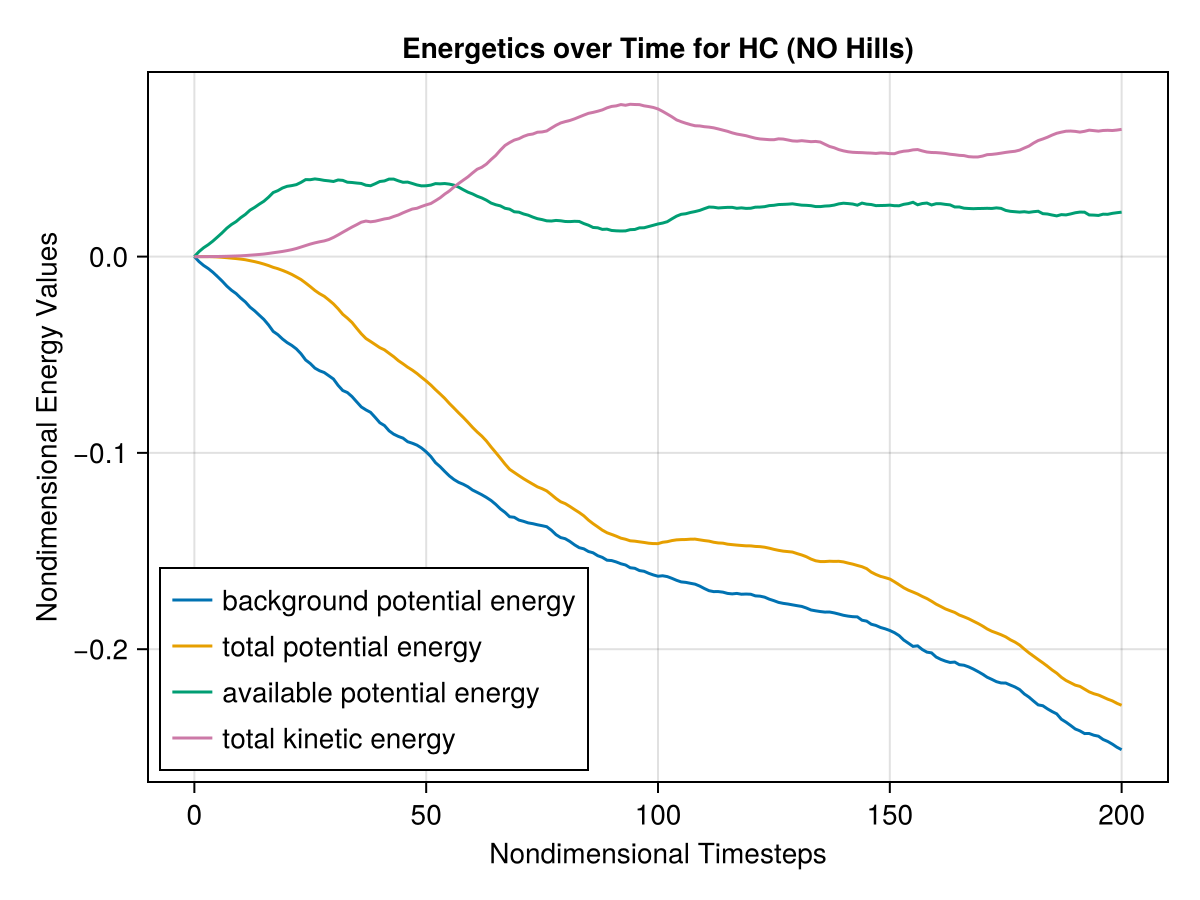

In [13]:
f = Figure()
ax = Axis(f[1,1], title="Energetics over Time for HC (NO Hills)", xlabel="Nondimensional Timesteps", ylabel="Nondimensional Energy Values")
lines!(ax, ds["time"][:], BPE, label="background potential energy")
lines!(ax, ds["time"][:], PE, label="total potential energy")
lines!(ax, ds["time"][:], PE.-BPE, label="available potential energy")
lines!(ax, ds["time"][:], KE, label="total kinetic energy")
axislegend(ax, position=(0, 0))

f

In [ ]:
#Nusselt Number: for THC I need data from diffusive and turbulent
ds_turb = NCDataset(string("/pub/hfdrake/code/HorizontalConvection/output/turbulent_h0.6_buoyancy.nc"));
ds_diff = NCDataset(string("/pub/hfdrake/code/HorizontalConvection/output/diffusive_h0.6_buoyancy.nc"));

times_turb = ds_turb["time"][:];
times_diff = ds_diff["time"][:];